# 재난현장 중증도 분류

0. 라이브러리 불러오기
1. 데이터 불러오기
2. 전처리
  2-1. T-RTS (외상 중증도 점수) 만들기
  2-2. 보행 가능 여부 만들기 (START 1번 분기)
3. 탐색·층별화
  3-4. 적색/황색 경계 (회색지대)
4. 모델링 — 분할 단위 비교, 템플릿 단위 층화 분할
5. 평가 — 오류의 방향, 변수 묶음 비교
6. 변수 확인
7. 규칙 추가 (START 규칙)
  7-2. 보행 여부·T-RTS로 규칙 보완
8. GroupKFold 검증
9. 과소분류 5% 목표 달성 설정 찾기
  9-2. 판정 문턱 조정 (가중치 대신 확률 기준)
10. 후송 순서 분석 — 분류 결과가 실제로 쓰이는가

## 0. 라이브러리

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt          # 그래프
from scipy import stats                  # 통계 검정 도구

# 한글 폰트 설정
import platform                                 # 지금 어떤 운영체제인지 확인하는 도구
시스템 = platform.system()                       # 'Darwin'(맥) / 'Windows' / 'Linux'(코랩)

if 시스템 == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif 시스템 == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    import os
    if not os.path.exists('/usr/share/fonts/truetype/nanum/NanumGothic.ttf'):
        os.system('apt-get -qq -y install fonts-nanum > /dev/null')   # 폰트 설치
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False              # 마이너스 기호가 깨지지 않게
print('폰트 설정 완료 :', plt.rcParams['font.family'][0])

폰트 설정 완료 : NanumGothic


## 1.데이터 불러오기 & 확인

In [6]:
df = pd.read_csv('SOMS_야전응급처치_타임라인_가상데이터.csv', encoding='utf-8-sig')
print('행 개수 :', df.shape[0])
print('열 개수 :', df.shape[1])
df.head()

행 개수 : 15106
열 개수 : 42


,시나리오ID,날짜,상황구분,이벤트ID,시나리오단계,영상_시작,영상_종료,식별시간,조치시작시간,조치완료시간,...,위협수준,장소,조명환경,후송우선순위,후송수단,인지→조치(초),조치소요(초),음성근거,근거수준,비고
0,SC-0001,2023-10-20,재난,EV-000001,현장(구조·1차 처치),03:09,03:27,03:21:53,03:22:00,03:22:08,...,군중 통제 완료,인근 상점 앞,헤드랜턴·가로등,-,-,7,8,"""하체까지 확인해""",영상+음성,NaN
1,SC-0001,2023-10-20,재난,EV-000002,현장→응급의료소 이동,03:53,04:36,03:22:29,03:22:34,03:23:13,...,군중 통제 완료,인근 상점 앞 → 현장응급의료소(대로변),헤드랜턴·가로등,우선,부축 보행(2인),5,39,"""이동합니다, 하나 둘 셋"" / ""라스트맨 확인""",영상+음성,부상 부위 좌우는 가상
2,SC-0001,2023-10-20,재난,EV-000003,현장응급의료소 운영,04:32,04:45,03:23:14,03:23:21,03:23:30,...,군중 통제 완료,현장응급의료소(대로변),헤드랜턴·가로등,-,-,7,9,"""손등에 번호 적어주세요""",음성,NaN
3,SC-0001,2023-10-20,재난,EV-000004,현장(구조·1차 처치),04:34,05:12,03:23:25,03:23:53,03:24:03,...,군중 통제 완료,인근 상점 앞,헤드랜턴·가로등,-,-,28,10,"""하체까지 확인해"" / ""블러드 스윕 하겠습니다""",영상+음성,NaN
4,SC-0001,2023-10-20,재난,EV-000005,현장(구조·1차 처치),04:39,04:46,03:23:28,03:23:29,03:23:36,...,군중 통제 완료,인근 상점 앞,헤드랜턴·가로등,-,-,1,7,"""블러드 스윕 하겠습니다""",영상+음성,부상 부위 좌우는 가상


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15106 entries, 0 to 15105
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   시나리오ID       15106 non-null  object
 1   날짜           15106 non-null  object
 2   상황구분         15106 non-null  object
 3   이벤트ID        15106 non-null  object
 4   시나리오단계       15106 non-null  object
 5   영상_시작        15106 non-null  object
 6   영상_종료        15106 non-null  object
 7   식별시간         15106 non-null  object
 8   조치시작시간       15106 non-null  object
 9   조치완료시간       15106 non-null  object
 10  조치자          15106 non-null  object
 11  조치자_역할       15106 non-null  object
 12  식별부상자        15106 non-null  object
 13  부상자ID        15106 non-null  object
 14  손등번호         15106 non-null  object
 15  환자평가         15106 non-null  object
 16  분류색상         15106 non-null  object
 17  의식수준(AVPU)   15106 non-null  object
 18  호흡수(회/분)     15106 non-null  int64 
 19  맥박수(회/분)     15106 non-nu

In [8]:
# 열마다 고유값이 몇 개인지 세어보기 (범주형인지 연속형인지 판단용)
for column in df.columns:
    count = df[column].nunique()
    print(f'{column:<15} 고유값 {count:>6}개')

시나리오ID          고유값    109개
날짜              고유값    107개
상황구분            고유값      4개
이벤트ID           고유값  15106개
시나리오단계          고유값     10개
영상_시작           고유값   2549개
영상_종료           고유값   2605개
식별시간            고유값  13409개
조치시작시간          고유값  13322개
조치완료시간          고유값  13354개
조치자             고유값     26개
조치자_역할          고유값     15개
식별부상자           고유값     37개
부상자ID           고유값     23개
손등번호            고유값     24개
환자평가            고유값      4개
분류색상            고유값      4개
의식수준(AVPU)      고유값      4개
호흡수(회/분)        고유값     31개
맥박수(회/분)        고유값     87개
수축기혈압(mmHg)     고유값     90개
구분              고유값      3개
유형              고유값     14개
MARCH코드         고유값     11개
부상기전            고유값    101개
부상부위            고유값     36개
조치내용            고유값    623개
사용도구            고유값     38개
조치결과            고유값    158개
다음권고조치          고유값     27개
상황              고유값     11개
세부상황            고유값     15개
위협수준            고유값     29개
장소              고유값    179개
조명환경            고유값      7개
후송우선순위          고유값 

In [9]:
# 목표 변수 확인

print(df['분류색상'].value_counts())
print()
print(df['분류색상'].value_counts(normalize=True).round(3))

# 환자평가는 분류색상과 같은 정보인지 교차표로 확인
print()
print(pd.crosstab(df['분류색상'], df['환자평가']))

분류색상
황색    6999
적색    4813
녹색    3272
흑색      22
Name: count, dtype: int64

분류색상
황색    0.463
적색    0.319
녹색    0.217
흑색    0.001
Name: proportion, dtype: float64

환자평가    긴급   비응급    응급  지연(기대)
분류색상                          
녹색       0  3272     0       0
적색    4813     0     0       0
황색       0     0  6999       0
흑색       0     0     0      22


## 2. 전처리

In [10]:
# 1 활력징후 0 은 '측정불가'이므로 결측으로 바꾸기

VITALS = ['호흡수(회/분)', '맥박수(회/분)', '수축기혈압(mmHg)']   # 활력징후 3개 열 이름

all_zero = (df[VITALS] == 0).all(axis=1)                  # 3개가 전부 0인 행 찾기 (측정 자체가 불가능했던 환자)

print('활력징후가 전부 0인 행 :', all_zero.sum(), '건')
print('그 행들의 분류색상     :', df[all_zero]['분류색상'].value_counts().to_dict())

df['측정불가'] = all_zero
df.loc[all_zero, VITALS] = np.nan                         # 0을 결측(NaN)으로 바꾸기 (평균이 왜곡 방지)

활력징후가 전부 0인 행 : 22 건
그 행들의 분류색상     : {'흑색': 22}


In [11]:
# 2. '-'는 결측이 아니라 '해당 없음'이므로 변경

# 컬럼별 '-'의미
na_meaning = {'후송우선순위':'미결정', '후송수단':'해당없음', '부상부위':'부위무관', '손등번호':'미부여', '다음권고조치':'없음',  '음성근거':'발화없음'}

for col, meaning in na_meaning.items():
    n_dash = (df[col] == '-').sum()
    df[col] = df[col].replace('-', meaning)
    print(f'{col:<10} : {n_dash:>6}건 → "{meaning}"')

후송우선순위     :   8798건 → "미결정"
후송수단       :  10106건 → "해당없음"
부상부위       :   6272건 → "부위무관"
손등번호       :   3601건 → "미부여"
다음권고조치     :   1250건 → "없음"
음성근거       :   1192건 → "발화없음"


In [12]:
# 3. 각 문자열을 진짜 시간으로 바꾸기

def to_seconds(text):                        # '03:21:53' → 12113 (초)
    parts = text.split(':')                  # ':' 기준으로 쪼개면 ['03','21','53']
    parts = [int(v) for v in parts]          # 숫자로 변환
    if len(parts) == 3:                      # 시:분:초 형태면
        return parts[0]*3600 + parts[1]*60 + parts[2]
    return parts[0]*60 + parts[1]            # 분:초 형태면 (영상 구간용)

date_col = pd.to_datetime(df['날짜'])        # 날짜 열을 날짜 타입으로

# 날짜 + 시각 을 합쳐서 완전한 시간 만들기
df['식별_시각']     = date_col + pd.to_timedelta(df['식별시간'].apply(to_seconds),     unit='s')
df['조치시작_시각'] = date_col + pd.to_timedelta(df['조치시작시간'].apply(to_seconds), unit='s')
df['조치완료_시각'] = date_col + pd.to_timedelta(df['조치완료시간'].apply(to_seconds), unit='s')

# 자정을 넘긴 처치는 완료 시각이 시작보다 앞서 보임 → 하루를 더해서 고침
past_midnight = df['조치완료_시각'] < df['조치시작_시각']
print('자정을 넘긴 행 :', past_midnight.sum(), '건')
df.loc[past_midnight, '조치완료_시각'] = df.loc[past_midnight, '조치완료_시각'] + pd.Timedelta(days=1)

# 제대로 바뀌었는지 검산 — 계산한 소요시간이 기록된 값과 같은지
calc = (df['조치완료_시각'] - df['조치시작_시각']).dt.total_seconds()
print('기록값과 다른 행 :', (calc != df['조치소요(초)']).sum(), '건')

자정을 넘긴 행 : 19 건
기록값과 다른 행 : 0 건


In [13]:
# 4. 새 변수 추가

# 쇼크지수 = 맥박 ÷ 수축기혈압. : 0.9 를 넘으면 쇼크 의심 (임상 지표)
df['쇼크지수'] = df['맥박수(회/분)'] / df['수축기혈압(mmHg)']

# 의식수준을 숫자로 : A(명료) > V(언어반응) > P(통증반응) > U(무반응)
avpu_map = {'A': 3, 'V': 2, 'P': 1, 'U': 0}
df['의식점수'] = df['의식수준(AVPU)'].map(avpu_map)

# 환자별로 '처음 발견된 시각'을 구해서, 각 처치까지 몇 분 지났는지 계산
df['환자키'] = df['시나리오ID'] + '_' + df['부상자ID']
first_seen = df.groupby('환자키')['식별_시각'].transform('min')   # 환자별 최초 시각
df['경과_분'] = (df['식별_시각'] - first_seen).dt.total_seconds() / 60

print(df[['쇼크지수', '의식점수', '경과_분']].describe().round(2))

           쇼크지수      의식점수      경과_분
count  15084.00  15106.00  15106.00
mean       1.08      2.16      8.60
std        0.31      0.99      6.57
min        0.46      0.00      0.00
25%        0.85      2.00      3.15
50%        1.03      2.00      7.87
75%        1.26      3.00     13.27
max        2.43      3.00     42.02


## 2-1. T-RTS (외상 중증도 점수) 만들기

In [14]:
# T-RTS (Triage Revised Trauma Score) — 현장에서 쓰는 표준 외상 점수
# ============================================================
# 호흡수 + 수축기혈압 + 의식(GCS) 세 가지를 각각 0~4점으로 바꿔 더한 점수 (0~12점)
# 점수가 낮을수록 위중. 보통 11점 이하를 '중증 의심'
#
# 주의: 이 데이터에는 GCS가 없고 AVPU만 있어서 아래처럼 근사함
#       A(명료)=15, V(언어반응)=12, P(통증반응)=8, U(무반응)=3
#       실제 GCS로 계산한 것이 아니므로 '근사값'이라고 밝혀야 함

gcs_map = {'A': 15, 'V': 12, 'P': 8, 'U': 3}     # AVPU를 GCS 점수로 근사
df['GCS추정'] = df['의식수준(AVPU)'].map(gcs_map)  # 의식 글자를 숫자로

def code_gcs(g):                  # GCS를 0~4점으로 변환
    if pd.isna(g):   return 0     # 값이 없으면 0점
    if g >= 13:      return 4     # 13~15 : 정상
    if g >= 9:       return 3     # 9~12
    if g >= 6:       return 2     # 6~8
    if g >= 4:       return 1     # 4~5
    return 0                      # 3 : 최저

def code_sbp(s):                  # 수축기혈압을 0~4점으로 변환
    if pd.isna(s):   return 0     # 측정불가는 0점 (활력징후 없음)
    if s > 89:       return 4     # 90 이상 : 정상
    if s >= 76:      return 3     # 76~89
    if s >= 50:      return 2     # 50~75
    if s >= 1:       return 1     # 1~49
    return 0                      # 0 : 맥압 없음

def code_rr(r):                   # 호흡수를 0~4점으로 변환
    if pd.isna(r):   return 0     # 측정불가는 0점
    if 10 <= r <= 29: return 4    # 10~29 : 정상
    if r > 29:       return 3     # 30 이상 : 빈호흡
    if r >= 6:       return 2     # 6~9
    if r >= 1:       return 1     # 1~5
    return 0                      # 0 : 무호흡

# 세 점수를 더해서 T-RTS 완성 (0~12점)
df['TRTS'] = (df['GCS추정'].map(code_gcs)
              + df['수축기혈압(mmHg)'].map(code_sbp)
              + df['호흡수(회/분)'].map(code_rr))

print('T-RTS 범위 :', df['TRTS'].min(), '~', df['TRTS'].max())
print(df.groupby('분류색상')['TRTS'].median().sort_values())   # 등급별 중앙값

T-RTS 범위 : 0 ~ 12
분류색상
흑색     0.0
적색     9.0
녹색    12.0
황색    12.0
Name: TRTS, dtype: float64


## 2-2. 보행 가능 여부 만들기 (START 1번 분기)

START 규칙의 **첫 질문 "스스로 걸을 수 있는가"** 관련 파생변수

In [52]:
# 후송수단 → 보행 가능 여부
move = df[~df['후송수단'].isin(['-', '해당없음']) & df['후송수단'].notna()]
first_move_time = move.groupby('환자키')['식별_시각'].min()                 # 환자별 첫 기록 시각
tri_time = df[df['유형'] == '환자분류'].groupby('환자키')['식별_시각'].min()    # 분류 시각

gap = (first_move_time - tri_time).dt.total_seconds() / 60               # 차이(분)
gap = gap.dropna()
print('후송수단 기록 시각 - 환자분류 시각')
print(f' 중앙값 {gap.median():.1f}분 / 분류보다 먼저 기록된 환자 {(gap < 0).sum()} / {len(gap)}명(군 데이터 포함)')
print('  기록되는 단계 :', move.groupby('환자키')['시나리오단계'].first().value_counts().to_dict())

# 후송수단을 '스스로 걸었는가'로 단순화 - 걸었는지(1) 아닌지(0)
walk_map = {
    '보행': 1, '부축 보행': 1, '후송 차량(경상자 버스)': 1,      # 스스로 이동
    '부축 보행(2인)': 0, '들것': 0, '구급차': 0,              # 스스로 이동 못 함
    '의무후송 헬기': 0, '구조정': 0,
}
first_move = move.sort_values('식별_시각').groupby('환자키')['후송수단'].first()
df['보행가능'] = df['환자키'].map(first_move).map(walk_map)       # 환자별로 붙이기

print('\n보행가능 분포 :', df.groupby('환자키')['보행가능'].first().value_counts().to_dict())

후송수단 기록 시각 - 환자분류 시각
 중앙값 -2.4분 / 분류보다 먼저 기록된 환자 1250 / 1250명(군 데이터 포함)
  기록되는 단계 : {'현장→응급의료소 이동': 835, 'POI→CCP 이동': 415}

보행가능 분포 : {0.0: 1039, 1.0: 211}


In [16]:
# 5. 복합 범주 쪼개서 원-핫
# '부상기전'에는 "둔상(압박)+압궤성 질식" 처럼 '+'로 이어붙은 값 -> 쪼개서 각각을 열로 만듬

split_list = df['부상기전'].str.split('+')      # '+' 기준으로 나누기 → 리스트

all_mech = []
for items in split_list:
    for mech in items:
        all_mech.append(mech.strip())

freq = pd.Series(all_mech).value_counts()
keep_mech = freq[freq >= 30].index
print('기전 종류', len(freq), '개 중', len(keep_mech), '개 사용')

for mech in keep_mech:
    df['기전_' + mech] = split_list.apply(lambda items: mech in [x.strip() for x in items])

print(df[['기전_' + g for g in keep_mech[:5]]].sum())

기전 종류 21 개 중 21 개 사용
기전_파편(폭발)    2484
기전_폭풍(폭발)    2155
기전_화상        2012
기전_둔상(추락)    1572
기전_압궤        1140
dtype: int64


In [17]:
# 6. 공공(재난·테러)만 남기기
# 군(전투·훈련사고)과 공공은 처치 단계 체계가 완전히 다르므로 분리

df['영역'] = df['상황구분'].replace({'전투': '군', '훈련사고': '군', '재난': '공공', '테러': '공공'})
print(df['영역'].value_counts())

pub = df[df['영역'] == '공공'].copy()                   # 공공만 골라서 새 표로
print('\n공공 데이터 :', pub.shape[0], '행')
print('환자 수     :', pub['환자키'].nunique(), '명')
print('시나리오    :', pub['시나리오ID'].nunique(), '개')

영역
공공    10021
군      5085
Name: count, dtype: int64

공공 데이터 : 10021 행
환자 수     : 850 명
시나리오    : 59 개


## 3-1 탐색

In [18]:
# 1. 분류색상별 활력징후 차이 보기
print(pub.groupby('분류색상')[VITALS + ['쇼크지수']].median().round(2))   # 등급별 중앙값

      호흡수(회/분)  맥박수(회/분)  수축기혈압(mmHg)  쇼크지수
분류색상                                       
녹색        18.0      89.0        121.0  0.73
적색        24.0     123.0         88.0  1.38
황색        22.0     104.0        105.0  0.99
흑색         NaN       NaN          NaN   NaN


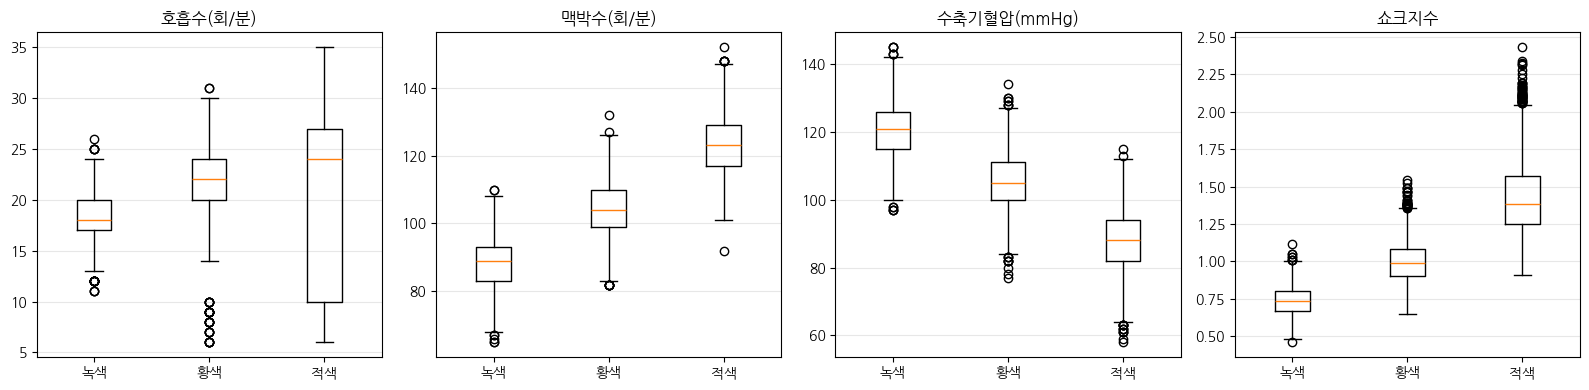

In [19]:
ORDER = ['녹색', '황색', '적색']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(VITALS + ['쇼크지수']):    # 활력징후 3개 + 쇼크지수
    box_data = [pub[pub['분류색상'] == g][col].dropna() for g in ORDER]
    axes[i].boxplot(box_data, tick_labels=ORDER)
    axes[i].set_title(col)
    axes[i].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# 2. 의식수준(AVPU)과 분류색상의 관계
ctab = pd.crosstab(pub['의식수준(AVPU)'], pub['분류색상'])
print('건수')
print(ctab.reindex(['A', 'V', 'P', 'U']))        # A→U 순서로 정렬

print('\n행 비율(%)')
ratio = pd.crosstab(pub['의식수준(AVPU)'], pub['분류색상'], normalize='index') * 100
print(ratio.reindex(['A', 'V', 'P', 'U']).round(1))

건수
분류색상          녹색    적색    황색  흑색
의식수준(AVPU)                      
A           2089     0  2776   0
V              0   701  1895   0
P              0  1633     0   0
U              0   912     0  15

행 비율(%)
분류색상          녹색     적색    황색   흑색
의식수준(AVPU)                        
A           42.9    0.0  57.1  0.0
V            0.0   27.0  73.0  0.0
P            0.0  100.0   0.0  0.0
U            0.0   98.4   0.0  1.6


             호흡수(회/분)  맥박수(회/분)  수축기혈압(mmHg)  쇼크지수  의식점수
호흡수(회/분)         1.00      0.12        -0.11  0.08 -0.06
맥박수(회/분)         0.12      1.00        -0.86  0.95 -0.83
수축기혈압(mmHg)     -0.11     -0.86         1.00 -0.95  0.80
쇼크지수             0.08      0.95        -0.95  1.00 -0.87
의식점수            -0.06     -0.83         0.80 -0.87  1.00


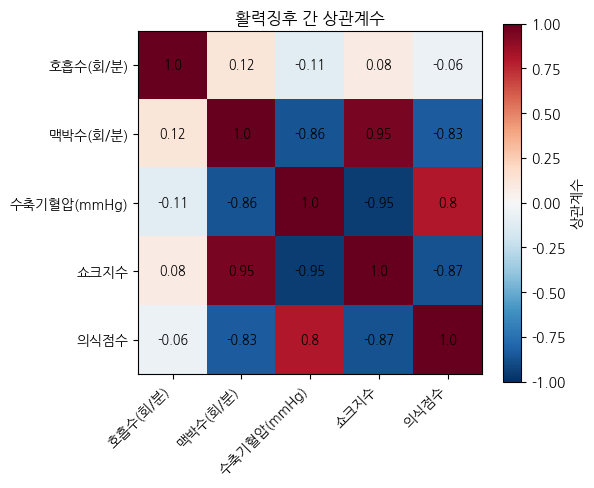


맥박수와 수축기혈압이 음(-)의 상관 → 둘을 나눈 쇼크지수 하나로 요약할 수 있습니다


In [21]:
# 3. 활력징후끼리 얼마나 겹치는가 (다중공선성)

corr = pub[VITALS + ['쇼크지수', '의식점수']].corr().round(2)   # 변수끼리 상관계수 계산
print(corr)

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)               # 색으로 표시
plt.colorbar(label='상관계수')
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr)), corr.index)
for i in range(len(corr)):                                     # 칸마다 숫자 써넣기
    for j in range(len(corr)):
        plt.text(j, i, corr.iloc[i, j], ha='center', va='center', fontsize=9)
plt.title('활력징후 간 상관계수')
plt.tight_layout()
plt.show()

print('\n맥박수와 수축기혈압이 음(-)의 상관 → 둘을 나눈 쇼크지수 하나로 요약 가능')

## 3-2 층별화

In [22]:
# 1. 재난 유형별로 중증도 구성이 다른지
triage = pub[pub['유형'] == '환자분류'].copy()   # 환자분류 이벤트 = 환자당 1건
print('분류 시점 행 :', len(triage), '건')

by_type = pd.crosstab(triage['상황'], triage['분류색상'], normalize='index') * 100
print()
print(by_type.round(1).sort_values('적색', ascending=False))

# 카이제곱 검정 — 재난 유형에 따라 중증도 구성이 정말 다른지 확인
table = pd.crosstab(triage['상황'], triage['분류색상'])
chi2, p_val, dof, expected = stats.chi2_contingency(table)
print(f'카이제곱 = {chi2:.1f}, p값 = {p_val:.3g}')
print('→ p값이 0.05보다 작으면 "재난 유형에 따라 중증도 구성이 다르다"고 볼 수 있음')

분류 시점 행 : 850 건

분류색상       녹색    적색    황색   흑색
상황                            
다중밀집 압사  12.0  45.1  38.3  4.5
테러       13.0  44.0  42.5  0.5
화재       12.5  43.8  42.2  1.6
화학사고      7.8  43.8  48.4  0.0
지진       17.4  35.5  45.7  1.4
산사태      26.5  28.6  42.9  2.0
홍수·수난    17.0  27.7  48.9  6.4
교통사고     32.1  22.6  45.2  0.0
카이제곱 = 54.1, p값 = 9.62e-05
→ p값이 0.05보다 작으면 "재난 유형에 따라 중증도 구성이 다르다"고 볼 수 있습니다


In [23]:
# 2. 구역(Zone)별로 어떤 처치를 하는지
pub['구역'] = pub['구분'].replace({'CUF': 'Hot Zone', 'TFC': 'Warm Zone', 'TEC': 'Cold Zone'})

by_zone = pd.crosstab(pub['구역'], pub['유형'], normalize='index') * 100
print(by_zone.round(1)[['대량출혈', '기도', '호흡', '순환', '재평가', '후송']])

유형         대량출혈    기도   호흡   순환   재평가    후송
구역                                         
Cold Zone   1.1   0.0  0.0  0.0  24.7  74.2
Hot Zone   98.0   0.0  0.0  0.0   0.0   0.0
Warm Zone  13.9  11.3  3.4  6.3  14.0  14.0


In [24]:
# 3. 역할별로 어떤 처치를 맡는지
for role in pub['조치자_역할'].unique():
    sub = pub[pub['조치자_역할'] == role]
    top3 = sub['유형'].value_counts(normalize=True).head(3)
    desc = ', '.join([f'{k} {v*100:.0f}%' for k, v in top3.items()])
    print(f'{role:<18} {desc}')

구급대 선임 구급대원        대량출혈 97%, 제독 3%
이송반                후송 100%
DMAT 간호사           재평가 32%, 환자분류 18%, 기도 13%
응급구조사              재평가 25%, 대량출혈 20%, 환자분류 11%
구조대원               대량출혈 97%, 제독 3%
DMAT 응급의학 전문의      재평가 34%, 환자분류 19%, 기도 10%
현장응급의료소장           후송 34%, 재평가 23%, 환자분류 11%
이송 통제관             후송 100%


In [25]:
# 4. K-means : 군집분석으로 환자군 분류
# ============================================================
# 정답(분류색상)을 모른다고 가정하고, 활력징후만으로 환자를 3무리로 묶고,
# 그 결과가 실제 분류색상과 얼마나 맞는지 확인 => 활력징후의 설명력 검증

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cl_data = triage[VITALS + ['의식점수']].dropna()

# 단위 맞추기
cl_scaled = StandardScaler().fit_transform(cl_data)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)   # 3무리로 나누기
cl_id = kmeans.fit_predict(cl_scaled)                      # 각 환자가 몇 번 무리인지

# 무리별 평균 활력징후 보기
cl_df = cl_data.copy()
cl_df['군집'] = cl_id
print('무리별 평균')
print(cl_df.groupby('군집').mean().round(1))

# 무리와 실제 분류색상을 비교
print('\n무리 × 실제 분류색상')
print(pd.crosstab(cl_id, triage.loc[cl_data.index, '분류색상']))

무리별 평균
    호흡수(회/분)  맥박수(회/분)  수축기혈압(mmHg)  의식점수
군집                                       
0        8.1     126.5         85.1   0.7
1       21.0      99.8        109.8   2.7
2       25.9     122.1         88.9   1.1

무리 × 실제 분류색상
분류색상    녹색   적색   황색
row_0               
0        0  139    5
1      136    7  295
2        0  184   69


## 3-3 가설 검정

In [26]:
# 가설 검정 — 등급 간 활력징후 차이가 통계적으로 유의한가
# 정규분포면 ANOVA, 아니면 비모수 검정(Kruskal-Wallis)

for col in VITALS + ['쇼크지수']:
    # 1) 정규성 검정 (표본 500개)
    sample = triage[col].dropna().sample(min(500, len(triage)), random_state=0)
    p_norm = stats.shapiro(sample)[1]

    # 2) 등급별로 값을 모아 세 집단 비교
    groups = [triage[triage['분류색상'] == g][col].dropna() for g in ORDER]

    if p_norm >= 0.05:                        # 정규분포면 ANOVA
        p_diff = stats.f_oneway(*groups)[1]
        method = 'ANOVA'
    else:                                     # 아니면 비모수 검정
        p_diff = stats.kruskal(*groups)[1]
        method = 'Kruskal-Wallis'

    norm_txt = '정규' if p_norm >= 0.05 else '정규 아님'
    print(f'{col:<15} 정규성 p={p_norm:7.4f} ({norm_txt:<6})  →  {method:<15} p={p_diff:.3g}')

print()
print('※ 활력징후 0(측정불가)을 결측 처리했기 때문에 맥박수·수축기혈압은 정규분포로 나옵니다.')
print('  0을 그대로 두면 분포가 찌그러져 전부 "정규 아님"으로 판정됨')

호흡수(회/분)        정규성 p= 0.0000 (정규 아님 )  →  Kruskal-Wallis  p=1e-12
맥박수(회/분)        정규성 p= 0.0575 (정규    )  →  ANOVA           p=8.01e-216
수축기혈압(mmHg)     정규성 p= 0.2959 (정규    )  →  ANOVA           p=1.16e-191
쇼크지수            정규성 p= 0.0000 (정규 아님 )  →  Kruskal-Wallis  p=9.84e-136

※ 활력징후 0(측정불가)을 결측 처리했기 때문에 맥박수·수축기혈압은 정규분포로 나옵니다.
  0을 그대로 두면 분포가 찌그러져 전부 "정규 아님"으로 판정됩니다.


## 3-4 적색/황색 경계 (회색지대)

In [53]:
# 1. 의식수준별로 등급이 얼마나 섞이는지
# 어느 구간에서 적색과 황색이 헷갈리는지 찾는 것이 목적

three = triage[triage['분류색상'] != '흑색']        # 흑색 빼고 3등급만

# 의식수준 x 분류색상 교차표
avpu_tab = pd.crosstab(three['의식수준(AVPU)'], three['분류색상'])[ORDER]
print('[의식수준별 등급 구성]')
print(avpu_tab)

print()
for lv in ['A', 'V', 'P', 'U']:                   # 의식 단계를 하나씩 보면서
    row = avpu_tab.loc[lv]                        # 그 단계의 등급별 인원
    n = row.sum()                                 # 그 단계 전체 인원
    top = row.idxmax()                            # 가장 많은 등급
    print(f'{lv} : {n:3d}명 → 최다 {top} {row[top]/n*100:.0f}%   '
          f'섞인 등급 수 {(row > 0).sum()}개')

# 섞이는 곳이 한 군데뿐이라는 것을 확인
print('\n※ P와 U는 100% 적색, A는 적색이 0명.')
print('   즉 적색/황색이 섞이는 곳은 의식 V 한 구간뿐')

[의식수준별 등급 구성]
분류색상         녹색   황색   적색
의식수준(AVPU)               
A           136  176    0
P             0    0  171
U             0    0  127
V             0  193   32

A : 312명 → 최다 황색 56%   섞인 등급 수 2개
V : 225명 → 최다 황색 86%   섞인 등급 수 2개
P : 171명 → 최다 적색 100%   섞인 등급 수 1개
U : 127명 → 최다 적색 100%   섞인 등급 수 1개

※ P와 U는 100% 적색, A는 적색이 0명.
   즉 적색/황색이 섞이는 곳은 의식 V 한 구간뿐입니다.


In [28]:
# 2. 의식 V 안에서 쇼크지수로 더 가를 수 있는가

v_only = three[three['의식수준(AVPU)'] == 'V']      # 의식 V인 환자만
print('의식 V :', len(v_only), '명 →', v_only['분류색상'].value_counts().to_dict())

# 쇼크지수를 구간으로 잘라서 등급 구성 보기
bins = [0, 0.9, 1.0, 1.1, 1.2, 1.3, 9]            # 나눌 경계값
v_bin = pd.cut(v_only['쇼크지수'], bins)            # 각 환자를 구간에 배정
print('\n[의식 V 안에서 쇼크지수 구간별]')
print(pd.crosstab(v_bin, v_only['분류색상']))

# 회색지대 정의 : 의식 V 이면서 쇼크지수 0.95~1.3
gray = three[(three['의식수준(AVPU)'] == 'V')
             & three['쇼크지수'].between(0.95, 1.3)]
print(f'\n회색지대(의식 V + 쇼크지수 0.95~1.3) : {len(gray)}명 '
      f'= 전체의 {len(gray)/len(three)*100:.0f}%')
print('  구성 :', gray['분류색상'].value_counts().to_dict())

# 이 구간에서 T-RTS가 추가로 갈라주는지 확인
print('\n[회색지대 안에서 T-RTS별 적색 비율]')
for t, g in gray.groupby('TRTS'):                  # T-RTS 점수별로 묶어서
    red_rate = (g['분류색상'] == '적색').mean() * 100
    print(f'  T-RTS {t} : 적색 {red_rate:4.0f}%  (n={len(g)})')

print('\n※ 쇼크지수와 의식만으로는 이 구간을 가를 수 없음')

의식 V : 225 명 → {'황색': 193, '적색': 32}

[의식 V 안에서 쇼크지수 구간별]
분류색상        적색  황색
쇼크지수              
(0.0, 0.9]   0   2
(0.9, 1.0]   0  28
(1.0, 1.1]   9  66
(1.1, 1.2]  11  54
(1.2, 1.3]   8  38
(1.3, 9.0]   4   5

회색지대(의식 V + 쇼크지수 0.95~1.3) : 211명 = 전체의 25%
  구성 : {'황색': 183, '적색': 28}

[회색지대 안에서 T-RTS별 적색 비율]
  T-RTS 8 : 적색    0%  (n=1)
  T-RTS 9 : 적색   78%  (n=9)
  T-RTS 10 : 적색   33%  (n=9)
  T-RTS 11 : 적색    9%  (n=192)

※ 쇼크지수와 의식만으로는 이 구간을 가를 수 없습니다.
  T-RTS가 같은 구간 안에서 추가 정보를 줍니다 → 입력 변수로 넣어봅니다.


In [55]:
# 보행 여부가 등급을 얼마나 가르는지 확인

chk = triage[triage['분류색상'] != '흑색']
tab = pd.crosstab(chk['보행가능'], chk['분류색상'])[ORDER]
print('[보행가능 x 분류색상]')
print(tab)
print()
print((tab.div(tab.sum(axis=1), axis=0) * 100).round(0))

[보행가능 x 분류색상]
분류색상   녹색   황색   적색
보행가능               
0.0     0  366  330
1.0   136    3    0

분류색상    녹색    황색    적색
보행가능                  
0.0    0.0  53.0  47.0
1.0   98.0   2.0   0.0


## 4. 모델링

In [30]:
# 모델링 준비 1 — 입력 변수와 목표 변수 정하기
# ============================================================
# 주의: 분류하는 그 순간에 알 수 없는 값은 모두 제외 (정답을 미리 아는 셈이 됨)
#
# [빼야 하는 것]
#  · 정답의 복사본        : 환자평가(분류색상과 1:1), 후송우선순위(적색→긴급 등 예외 0건)
#  · 글자에 정답이 들어감  : 조치내용, 조치결과, 사용도구, 다음권고조치, 음성근거, 비고
#  · 분류 후에 생김       : 손등번호, 후송수단
#  · 조치가 끝나야 생김    : 조치완료시간, 인지→조치(초), 조치소요(초)
#  · 그 행의 처치 선택     : 유형, MARCH코드, 조치자, 조치자_역할
#                        (무슨 처치를 했는지는 이미 중증도를 보고 정한 것)
#
# [넣어도 되는 것] 분류하는 순간에 눈으로 재거나 볼 수 있는 값
#  · 쇼크지수 : 맥박 ÷ 혈압
#  · 경과_분  : 발견 후 지금까지 걸린 시간 (미래 정보가 아님)
#  · TRTS    : 호흡·혈압·의식만으로 계산한 표준 외상 점수 (2-1에서 생성)

FEATURES = ['의식점수', '호흡수(회/분)', '맥박수(회/분)', '수축기혈압(mmHg)',
            '쇼크지수', '경과_분', 'TRTS']
TARGET = '분류색상'

# 등급을 숫자로 바꾸는 표 (어느 방향으로 틀렸는지 비교할 때 계속 씁니다)
LEVEL = {'녹색': 0, '황색': 1, '적색': 2}

# 흑색은 모델이 아니라 규칙이 담당하므로 제외 (7절에서 START 규칙이 처리)
#  - 공공 환자 850명은 전원 적색·황색·녹색으로 시작
#  - 흑색 15명도 첫 접촉 때는 적색이었고, 재평가에서 「기도 개방 후에도 무호흡」으로 바뀜
#  - 즉 흑색은 예측 대상이 아니라 처치를 해보고 확인한 결과
data = triage[triage['분류색상'] != '흑색'].copy()
print('학습에 쓸 환자 :', len(data), '명')
print(data[TARGET].value_counts())

학습에 쓸 환자 : 835 명
분류색상
황색    369
적색    330
녹색    136
Name: count, dtype: int64


### 나누는 기준을 바꾸면 점수가 달라지는가

"템플릿 단위로 나눠야 한다"고 정하기 전에, 정말 차이가 있는지 확인

In [54]:
# 분할 단위 비교 — 가정하지 말고 직접 재보기
# ============================================================
# 같은 모델, 같은 변수로 '나누는 기준'만 바꿔서 점수를 비교
# 무작위 분할 점수가 훨씬 높으면 = 누수가 있다는 뜻

from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

X_cmp = data[FEATURES].fillna(data[FEATURES].median())   # 결측 채우기
y_cmp = data[TARGET]                                     # 정답
rf_cmp = RandomForestClassifier(n_estimators=300, random_state=0)

# (이름, 나누는 방법, 묶는 기준) 네 가지를 차례로 시험
ways = [
    ('행 무작위',   KFold(4, shuffle=True, random_state=0), None),
    ('환자 단위',   GroupKFold(4), data['환자키']),
    ('시나리오 단위', GroupKFold(4), data['시나리오ID']),
    ('템플릿 단위',  GroupKFold(4), data['세부상황']),
]

accs = []                                        # 정확도를 모아둘 곳
for name, cv, groups in ways:                    # 방법을 하나씩 꺼내서
    p = cross_val_predict(rf_cmp, X_cmp, y_cmp, cv=cv, groups=groups)
    accs.append(accuracy_score(y_cmp, p) * 100)
    yn = y_cmp.map(LEVEL).values                 # 정답을 숫자로
    pn = pd.Series(p).map(LEVEL).values          # 예측을 숫자로
    print(f'{name:<10} 정확도 {accuracy_score(y_cmp, p)*100:5.2f}%   '
          f'macro-F1 {f1_score(y_cmp, p, average="macro"):.3f}   '
          f'과소분류 {(pn < yn).mean()*100:.2f}%')

print(f'\n※ 가장 높은 방법과 낮은 방법의 정확도 차이 : {max(accs) - min(accs):.2f}%p')

행 무작위      정확도 90.06%   macro-F1 0.881   과소분류 5.51%
환자 단위      정확도 89.46%   macro-F1 0.872   과소분류 5.51%
시나리오 단위    정확도 89.58%   macro-F1 0.874   과소분류 5.39%
템플릿 단위     정확도 90.06%   macro-F1 0.882   과소분류 4.79%

※ 가장 높은 방법과 낮은 방법의 정확도 차이 : 0.60%p


In [32]:
# 모델링 준비 2 — 학습용과 검증용 나누기
# ============================================================
# 무작위로 나누면 같은 시나리오(대본)가 양쪽에 섞여서 점수가 부풀려질 수 있음
# → 시나리오 템플릿 단위로 통째로 갈라놓기
#
# StratifiedGroupKFold : 템플릿을 통째로 가르면서 + 등급 비율도 최대한 맞춰줌

from sklearn.model_selection import StratifiedGroupKFold

templates = data['세부상황'].unique()          # 공공 템플릿 8종
print('템플릿 종류 :', len(templates), '개')
for t in templates:
    print('  -', t[:40])

# 템플릿을 통째로 유지하면서 4묶음으로 가르고, 그중 첫 묶음을 검증용으로 사용
sgk = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
train_idx, test_idx = next(sgk.split(data, data[TARGET], groups=data['세부상황']))

train_df = data.iloc[train_idx]                # 학습용
test_df  = data.iloc[test_idx]                 # 검증용

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f'\n학습 {len(X_train)}명 / 검증 {len(X_test)}명')
print('검증용 템플릿 :', [t[:25] for t in test_df['세부상황'].unique()])
print('겹치는 템플릿 :', len(set(train_df['세부상황']) & set(test_df['세부상황'])), '개')

# 등급 비율이 양쪽에서 비슷한지 확인
print('\n[등급 비율]')
print(pd.DataFrame({'학습': y_train.value_counts(normalize=True),
                    '검증': y_test.value_counts(normalize=True)}).round(3))

템플릿 종류 : 8 개
  - 축제 인파 밀집 골목 압사 사고, 다수 심정지·호흡곤란
  - 고층 주상복합 대형 화재, 연기흡입·화상 다수 발생
  - 지하철역 폭발물 테러, 역사 내 다수사상자 처치·반출
  - 산업단지 유해화학물질(염소) 누출, 오염 환자 제독·처치
  - 고속도로 안개 속 30중 연쇄추돌, 차량 내 끼임 환자 구출
  - 규모 6.8 지진 후 공동주택 붕괴, 매몰자 구조·처치
  - 태풍 후 산사태로 마을 주택 매몰, 토사 내 요구조자 구조
  - 집중호우 하천 범람, 고립 주민 수상 구조·익수 환자 처치

학습 791명 / 검증 44명
검증용 템플릿 : ['집중호우 하천 범람, 고립 주민 수상 구조·익']
겹치는 템플릿 : 0 개

[등급 비율]
         학습     검증
분류색상              
황색    0.437  0.523
적색    0.401  0.295
녹색    0.162  0.182


In [33]:
#  모델 학습 — 여러 모델을 비교

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

# 결측(측정불가)은 각 열의 중앙값으로 채우기
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

# class_weight : 적색(긴급)을 틀리면 몇 배로 벌점을 줄지
# 값을 키울수록 모델이 "적색을 놓치는 것"을 더 크게 손해로 봄
models = {
    '최빈값(하한선)': DummyClassifier(strategy='most_frequent'),   # 아무것도 학습 안 한 바닥 점수
    '의사결정나무':   DecisionTreeClassifier(max_depth=5, random_state=0),
    '랜덤포레스트':   RandomForestClassifier(n_estimators=300, random_state=0),
    '로지스틱 회귀':  LogisticRegression(max_iter=3000),
    '랜덤포레스트(적색3배)':  RandomForestClassifier(n_estimators=300, random_state=0,
                                                 class_weight={'녹색':1, '황색':1, '적색':3}),
    '랜덤포레스트(적색6배)':  RandomForestClassifier(n_estimators=300, random_state=0,
                                                 class_weight={'녹색':1, '황색':1, '적색':6}),
    '랜덤포레스트(적색10배)': RandomForestClassifier(n_estimators=300, random_state=0,
                                                 class_weight={'녹색':1, '황색':1, '적색':10}),
}

try:
    from xgboost import XGBClassifier          # 부스팅 계열 모델
    models['XGBoost'] = XGBClassifier(n_estimators=300, max_depth=4,
                                      learning_rate=0.1, random_state=0)
except ImportError:
    print('(xgboost 가 설치돼 있지 않아 건너뜁니다)')

to_num   = {'녹색': 0, '황색': 1, '적색': 2}   # XGBoost 는 글자 정답을 못 받아서
to_label = {0: '녹색', 1: '황색', 2: '적색'}   # 숫자로 바꿨다가 다시 글자로

preds = {}                                     # 모델별 예측을 담아둘 곳
for name, model in models.items():             # 모델을 하나씩 꺼내서
    if name == 'XGBoost':                      # XGBoost 만 숫자 정답으로 학습
        model.fit(X_train, y_train.map(to_num))
        pred = pd.Series(model.predict(X_test)).map(to_label).values
    else:
        model.fit(X_train, y_train)            # 나머지는 글자 그대로
        pred = model.predict(X_test)           # 검증 데이터로 예측
    preds[name] = pred                         # 나중에 쓰려고 저장
    # macro-F1 : 세 등급을 똑같이 중요하게 보고 매긴 점수 (정확도보다 공정)
    print(f'{name:<20} 정확도 {accuracy_score(y_test, pred)*100:5.2f}%   '
          f'macro-F1 {f1_score(y_test, pred, average="macro"):.3f}')

print('\n※ 최빈값만 찍어도 정확도 40%대 → 정확도만 보면 안 되는 이유')

최빈값(하한선)             정확도 52.27%   macro-F1 0.229
의사결정나무               정확도 79.55%   macro-F1 0.771
랜덤포레스트               정확도 84.09%   macro-F1 0.814
로지스틱 회귀              정확도 81.82%   macro-F1 0.804
랜덤포레스트(적색3배)         정확도 84.09%   macro-F1 0.814
랜덤포레스트(적색6배)         정확도 81.82%   macro-F1 0.791
랜덤포레스트(적색10배)        정확도 81.82%   macro-F1 0.791
XGBoost              정확도 86.36%   macro-F1 0.845

※ 최빈값만 찍어도 정확도가 40%대입니다. 정확도만 보면 안 되는 이유입니다.


## 5. 평가

In [34]:
# '어느 방향으로 틀렸는가'
# 위중한 환자를 가볍게 본 것(과소분류)  => 사망,
# 가벼운 환자를 위중하게 본 것(과대분류) => 자원 낭비
# ============================================================
# LEVEL 은 모델링 준비 1(4절)에서 정의함 : {'녹색':0, '황색':1, '적색':2}

under_by_model = {}                            # 모델별 과소분류율을 담아둘 곳
for name, pred in preds.items():
    y_num = y_test.map(LEVEL).values           # 실제 등급을 숫자로
    p_num = pd.Series(pred).map(LEVEL).values  # 예측 등급을 숫자로

    under = (p_num < y_num).mean() * 100       # 실제보다 낮게 본 비율
    over  = (p_num > y_num).mean() * 100       # 실제보다 높게 본 비율
    under_by_model[name] = under

    is_red   = (y_test == '적색')              # 진짜 적색인 환자
    red_miss = (is_red & (pd.Series(pred, index=y_test.index) != '적색')).sum()
    f1m      = f1_score(y_test, pred, average='macro')   # 세 등급 평균 F1

    mark = '  ← 기준 통과' if under < 5 else ''
    print(f'{name:<20} 과소분류 {under:5.1f}%   과대분류 {over:5.1f}%   '
          f'macro-F1 {f1m:.3f}   적색 놓침 {red_miss}명 / {is_red.sum()}명{mark}')

print('\n※ 미국외과학회 기준 : 과소분류 5% 미만, 과대분류 25~35%')
print('  과대분류 예산이 많이 남아 있으므로 가중치를 더 올려도 됨')

# 정확도가 아니라 '과소분류가 가장 낮은' 모델을 고르기
# (최빈값 하한선은 전부 황색으로 찍어서 과소분류가 낮게 나오므로 후보에서 제외)
cand = {k: v for k, v in under_by_model.items() if k != '최빈값(하한선)'}
best = min(cand, key=cand.get)
print(f'\n선택한 모델 : {best}  (과소분류 {cand[best]:.1f}%)')

최빈값(하한선)             과소분류  29.5%   과대분류  18.2%   macro-F1 0.229   적색 놓침 13명 / 13명
의사결정나무               과소분류  11.4%   과대분류   9.1%   macro-F1 0.771   적색 놓침 2명 / 13명
랜덤포레스트               과소분류   6.8%   과대분류   9.1%   macro-F1 0.814   적색 놓침 1명 / 13명
로지스틱 회귀              과소분류  11.4%   과대분류   6.8%   macro-F1 0.804   적색 놓침 2명 / 13명
랜덤포레스트(적색3배)         과소분류   6.8%   과대분류   9.1%   macro-F1 0.814   적색 놓침 1명 / 13명
랜덤포레스트(적색6배)         과소분류   9.1%   과대분류   9.1%   macro-F1 0.791   적색 놓침 1명 / 13명
랜덤포레스트(적색10배)        과소분류   9.1%   과대분류   9.1%   macro-F1 0.791   적색 놓침 1명 / 13명
XGBoost              과소분류   9.1%   과대분류   4.5%   macro-F1 0.845   적색 놓침 1명 / 13명

※ 미국외과학회 기준 : 과소분류 5% 미만, 과대분류 25~35%
  과대분류 예산이 많이 남아 있으므로 가중치를 더 올려도 됩니다

선택한 모델 : 랜덤포레스트  (과소분류 6.8%)


### 변수를 추가하면 정말 좋아지는가

T-RTS와 보행가능을 넣은 것과 넣지 않은 것을 같은 방식으로 비교

In [56]:
# 변수 묶음 비교 — 넣을지 말지를 숫자로 정하기

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

base6 = ['의식점수', '호흡수(회/분)', '맥박수(회/분)', '수축기혈압(mmHg)', '쇼크지수', '경과_분']

sets = [
    ('기본 6개',   base6),
    ('+ T-RTS',   base6 + ['TRTS']),
    ('+ 보행가능',  base6 + ['보행가능']),
    ('+ 둘 다',    base6 + ['TRTS', '보행가능']),
]

y_fc = data[TARGET]                                  # 정답
yn_fc = y_fc.map(LEVEL).values                       # 정답을 숫자로
red_fc = (yn_fc == 2)                                # 진짜 적색 위치

for name, cols in sets:                              # 변수 묶음을 하나씩
    X_fc = data[cols].fillna(data[cols].median())    # 결측 채우기
    m = RandomForestClassifier(n_estimators=300, random_state=0,
                               class_weight={'녹색': 1, '황색': 1, '적색': 10})
    p = cross_val_predict(m, X_fc, y_fc, cv=GroupKFold(4), groups=data['세부상황'])
    pn = pd.Series(p).map(LEVEL).values               # 예측을 숫자로
    print(f'{name:<9} 정확도 {accuracy_score(y_fc, p)*100:5.2f}%  '
          f'macro-F1 {f1_score(y_fc, p, average="macro"):.3f}  '
          f'과소 {(pn < yn_fc).mean()*100:4.2f}%  과대 {(pn > yn_fc).mean()*100:4.2f}%  '
          f'적색놓침 {(pn[red_fc] < 2).sum():2d}명')

기본 6개     정확도 88.86%  macro-F1 0.870  과소 6.71%  과대 4.43%  적색놓침 30명
+ T-RTS   정확도 89.58%  macro-F1 0.877  과소 5.51%  과대 4.91%  적색놓침 23명
+ 보행가능    정확도 94.73%  macro-F1 0.955  과소 4.19%  과대 1.08%  적색놓침 32명
+ 둘 다     정확도 95.45%  macro-F1 0.961  과소 3.11%  과대 1.44%  적색놓침 23명


※ 두 변수를 넣으면 과소분류가 3.71% → 1.56%로 내려감.  
  - 적색 놓침 : 9명 → 10명으로 줄지 않음.  
  - 좋아진 것 : 녹색/황색 경계
  - 위험한 적색 경계(회색지대)는 그대로

In [36]:
# 선택한 모델의 혼동행렬 상세
cm = confusion_matrix(y_test, preds[best], labels=ORDER)
print(pd.DataFrame(cm, index=['실제_'+g for g in ORDER], columns=['예측_'+g for g in ORDER]))
print()
print(classification_report(y_test, preds[best], digits=3))

       예측_녹색  예측_황색  예측_적색
실제_녹색      5      3      0
실제_황색      2     20      1
실제_적색      0      1     12

              precision    recall  f1-score   support

          녹색      0.714     0.625     0.667         8
          적색      0.923     0.923     0.923        13
          황색      0.833     0.870     0.851        23

    accuracy                          0.841        44
   macro avg      0.824     0.806     0.814        44
weighted avg      0.838     0.841     0.839        44



## 6. 변수 확인

쇼크지수           0.219
의식점수           0.198
TRTS           0.181
맥박수(회/분)       0.150
수축기혈압(mmHg)    0.129
호흡수(회/분)       0.065
경과_분           0.058
dtype: float64


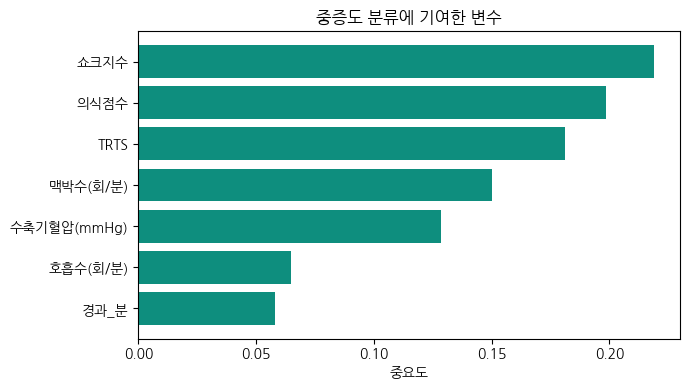

In [37]:
# 변수 중요도 확인
rf = models['랜덤포레스트']
importance = pd.Series(rf.feature_importances_, index=FEATURES)  # 변수별 중요도
importance = importance.sort_values(ascending=False)             # 큰 순서로 정렬

print(importance.round(3))

plt.figure(figsize=(7, 4))
plt.barh(importance.index[::-1], importance.values[::-1], color='#0E8E7E')   # [::-1]은 순서 뒤집기
plt.xlabel('중요도')
plt.title('중증도 분류에 기여한 변수')
plt.tight_layout()
plt.show()

In [38]:
# 변수 선별 — 상호정보량과 순열중요도 비교
# ============================================================
# 상호정보량 : "정답과 얼마나 관련 있나"
# 순열중요도 : "그 변수를 망가뜨리면 성능이 얼마나 떨어지나"
# 둘이 다르면, 관련은 있어 보여도 실제로는 도움이 안 되는 변수

from sklearn.feature_selection import mutual_info_classif    # 상호정보량
from sklearn.inspection import permutation_importance        # 순열중요도

# 상호정보량 계산 (학습 데이터 기준)
mi = mutual_info_classif(X_train, y_train, random_state=0)
mi = pd.Series(mi, index=FEATURES)

# 순열 중요도 계산 (검증 데이터에서 변수를 섞어보며 성능 하락폭 측정)
perm = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=0)
perm = pd.Series(perm.importances_mean, index=FEATURES)

compare = pd.DataFrame({'상호정보량': mi.round(3),
                        '순열 중요도': perm.round(3),
                        '모델 중요도': importance.round(3)})
print(compare.sort_values('순열 중요도', ascending=False))


             상호정보량  순열 중요도  모델 중요도
의식점수         0.672   0.110   0.198
TRTS         0.670   0.094   0.181
호흡수(회/분)     0.462   0.016   0.065
경과_분         0.002   0.015   0.058
쇼크지수         0.662   0.000   0.219
맥박수(회/분)     0.570  -0.008   0.150
수축기혈압(mmHg)  0.545  -0.025   0.129

순열 중요도가 0 이하면 그 변수는 빼는 편이 낫습니다


### 순열 중요도가 0이면 정말 빼도 되는가

쇼크지수가 **상호정보량 1위(0.683), 모델 중요도 1위(0.229)인데 순열 중요도는 0.017**로 사실상 0임.
세 지표가 서로 다른 질문에 답하기 때문.

| 지표 | 재는 질문 |
| --- | --- |
| 모델 중요도 (지니) | 나무가 가지 칠 때 이 변수를 얼마나 썼나 |
| 상호정보량 | **혼자서** 정답과 얼마나 관련 있나 |
| 순열 중요도 | **나머지가 다 있을 때** 이것만 망가뜨리면 얼마나 나빠지나 |

앞의 둘은 "혼자 뒀을 때", 순열 중요도는 "동료가 다 있을 때"를 잼.
쇼크지수 = 맥박 ÷ 혈압인데 **맥박과 혈압이 따로 또 들어 있어서** 섞어놔도 모델이 복원해버림.

**순열 중요도 0 = 정보 없음이 아니라 대체 가능.** 빼도 되는지는 아래처럼 빼서 돌려보고 판단.

In [ ]:
# 정말 빼도 되는지 — 상관을 보고, 그룹으로 빼서 돌려보기
# 순열 중요도 0은 (1) 진짜 쓸모없음 (2) 대체 가능(중복) 둘 중 하나
# 가르는 방법은 '빼고 돌려보기' 하나뿐

# 1) 상관부터. |상관| >= 0.9 면 순열 중요도를 믿으면 안 됨
dup_cols = ['맥박수(회/분)', '수축기혈압(mmHg)', '쇼크지수', 'TRTS']
print('[스피어만 상관]')
print(data[dup_cols].corr('spearman').round(2))

# 2) 하나씩 / 그룹째 빼가며 성능 비교
sets_chk = [
    ('전체 (현재)',            FEATURES),
    ('− 쇼크지수',             [c for c in FEATURES if c != '쇼크지수']),
    ('− 맥박·혈압',            [c for c in FEATURES if c not in ('맥박수(회/분)', '수축기혈압(mmHg)')]),
    ('− 셋 다 (그룹째)',        [c for c in FEATURES if c not in ('맥박수(회/분)', '수축기혈압(mmHg)', '쇼크지수')]),
    ('쇼크지수 단독',           ['쇼크지수']),
]

yn_chk = data[TARGET].map(LEVEL).values                  # 정답을 숫자로
print('\n[변수를 빼가며 비교 — 835명, 템플릿 GroupKFold]')
for name, cols in sets_chk:                              # 구성을 하나씩 꺼내서
    X_chk = data[cols].fillna(data[cols].median())       # 결측 채우기
    m = RandomForestClassifier(n_estimators=300, random_state=0,
                               class_weight={'녹색': 1, '황색': 1, '적색': 10})
    p = cross_val_predict(m, X_chk, data[TARGET], cv=GroupKFold(4), groups=data['세부상황'])
    pn = pd.Series(p).map(LEVEL).values                  # 예측을 숫자로
    print(f'  {name:<18} macro-F1 {f1_score(data[TARGET], p, average="macro"):.3f}   '
          f'과소분류 {(pn < yn_chk).mean()*100:4.2f}%   적색놓침 {(pn[yn_chk == 2] < 2).sum():2d}명')

**읽는 법**

- 쇼크지수만 빼면 거의 안 변함 (0.871 → 0.865)
- 맥박·혈압을 빼고 쇼크지수만 남겨도 거의 안 변함 (0.864)
- **셋을 다 빼면 확 떨어짐 (0.773)** → 셋은 서로 바꿔 끼울 수 있고, 그룹 자체는 중요
- 쇼크지수 단독으로도 0.742 (최빈값 하한선 0.200) → 정보가 없는 변수가 아님

**결론 : 성능만 보면 빼도 되지만 남김**

- 쇼크지수는 0.9라는 임상 기준선이 있어 현장에서 바로 읽힘
- 등급별 중앙값도 0.73 / 0.99 / 1.38 로 깔끔하게 갈림
- 성능이 같으면 해석이 쉬운 쪽을 남기는 것이 나음

## 7. 규칙 추가 (START 규칙)

- 다수사상자 현장에서 쓰는 국제 표준 분류법

In [39]:
# '왜 그렇게 판단했는지' 설명

def start_triage(avpu, rr, pr, sbp):
    if pd.isna(rr) or rr == 0:      # 숨을 안 쉬면
        return '흑색'
    if rr > 30 or rr < 10:          # 호흡수가 비정상이면
        return '적색'
    if sbp < 90:                    # 혈압이 낮으면 (관류 불량)
        return '적색'
    if pr > 120:                    # 맥박이 너무 빠르면
        return '적색'
    if avpu in ['P', 'U']:          # 명령을 따르지 못하면
        return '적색'
    # 여기까지 걸리지 않았고 모든 수치가 정상 범위면 녹색
    if avpu == 'A' and 10 <= rr <= 26 and pr <= 110 and sbp >= 95:
        return '녹색'
    return '황색'                   # 나머지는 황색

# 검증 데이터에 규칙 적용
rule_pred = []
for i in test_df.index:             # 검증 데이터를 한 줄씩 돌면서
    res = start_triage(test_df.loc[i, '의식수준(AVPU)'],
                       test_df.loc[i, '호흡수(회/분)'],
                       test_df.loc[i, '맥박수(회/분)'],
                       test_df.loc[i, '수축기혈압(mmHg)'])
    rule_pred.append(res)           # 결과를 목록에 담기
rule_pred = pd.Series(rule_pred, index=test_df.index)

print('START 규칙 정확도 :', f'{accuracy_score(y_test, rule_pred)*100:.2f}%')

START 규칙 정확도 : 70.45%


In [40]:
# 규칙 + 모델 결합 — 둘 중 더 위중한 쪽을 고르기
model_pred = pd.Series(preds[best], index=test_df.index)

combo_pred = []
for i in test_df.index:
    rule_lv  = LEVEL.get(rule_pred[i], 3)          # 규칙이 매긴 등급의 숫자
    model_lv = LEVEL.get(model_pred[i], 3)         # 모델이 매긴 등급의 숫자
    higher   = max(rule_lv, model_lv)              # 더 위중한 쪽 고르기
    back = {0: '녹색', 1: '황색', 2: '적색', 3: '흑색'}
    combo_pred.append(back[higher])
combo_pred = pd.Series(combo_pred, index=test_df.index)

# 세 방법을 한 표로 비교하기
summary = []
for name, pred in [('START 규칙', rule_pred), (best, model_pred), ('규칙+모델 결합', combo_pred)]:
    y_num  = y_test.map(LEVEL).values
    p_num  = pred.map(LEVEL).values
    is_red = (y_test == '적색')
    summary.append({
        '방법': name,
        '정확도': round(accuracy_score(y_test, pred)*100, 1),
        '과소분류%': round((p_num < y_num).mean()*100, 1),
        '과대분류%': round((p_num > y_num).mean()*100, 1),
        '적색놓침': int((is_red & (pred != '적색')).sum()),
    })
print(pd.DataFrame(summary).to_string(index=False))

      방법  정확도  과소분류%  과대분류%  적색놓침
START 규칙 70.5   27.3    2.3     0
  랜덤포레스트 84.1    6.8    9.1     1
규칙+모델 결합 86.4    4.5    9.1     0


In [41]:
# 정리
print('[분석 요약]')
print(f'· 공공 데이터 {len(pub):,}건, 환자 {pub["환자키"].nunique()}명, 템플릿 8종')
print(f'· 학습 {len(X_train)}명 / 검증 {len(X_test)}명 (시나리오 템플릿 단위로 분리)')
print(f'· 목표 변수 : 분류색상 (적색·황색·녹색)')
print(f'· 입력 변수 : {", ".join(FEATURES)}')
print()
print('[주의] 이 데이터는 실제 기록 35행을 바탕으로 만든 가상 데이터')
print('       위 성능은 "가상 데이터 기준 내부 검증치"이며 실제 현장 성능이 아닙니다.')

[분석 요약]
· 공공 데이터 10,021건, 환자 850명, 템플릿 8종
· 학습 791명 / 검증 44명 (시나리오 템플릿 단위로 분리)
· 목표 변수 : 분류색상 (적색·황색·녹색)
· 입력 변수 : 의식점수, 호흡수(회/분), 맥박수(회/분), 수축기혈압(mmHg), 쇼크지수, 경과_분, TRTS

[주의] 이 데이터는 실제 기록 35행을 바탕으로 만든 가상 데이터입니다.
       위 성능은 "가상 데이터 기준 내부 검증치"이며 실제 현장 성능이 아닙니다.


## 7-2. START 규칙 보완 — 보행 여부와 T-RTS

지금 쓰는 `start_triage`는 보행 여부가 없어서 "AVPU=A + 활력징후 정상"으로 대신하고 있었음.
실제 보행 여부를 넣으면 규칙이 얼마나 좋아지는지 봅니다.

In [42]:
# START 1번 분기를 실제 보행 여부로 바꾸면
# ============================================================
def start_walk(avpu, rr, pr, sbp, walk):
    if pd.isna(rr) or rr == 0:   return '흑색'      # 숨을 안 쉬면
    if walk == 1:                return '녹색'      # START 1번: 스스로 걸으면 경증
    if rr > 30 or rr < 10:       return '적색'      # 호흡수가 비정상이면
    if pd.isna(sbp) or sbp < 90: return '적색'      # 혈압이 낮으면
    if pd.isna(pr) or pr > 120:  return '적색'      # 맥박이 너무 빠르면
    if avpu in ['P', 'U']:       return '적색'      # 명령을 따르지 못하면
    return '황색'                                   # 나머지는 황색

three_all = triage[triage['분류색상'] != '흑색']     # 3등급 전체 835명
yn_r = three_all['분류색상'].map(LEVEL).values       # 정답을 숫자로
red_r = (yn_r == 2)                                 # 진짜 적색 위치

for name in ['기존 START (보행=AVPU 대치)', 'START + 실제 보행여부']:
    pred_r = []
    for i in three_all.index:                        # 한 줄씩 규칙 적용
        r = three_all.loc[i]
        if name.startswith('기존'):
            pred_r.append(start_triage(r['의식수준(AVPU)'], r['호흡수(회/분)'],
                                       r['맥박수(회/분)'], r['수축기혈압(mmHg)']))
        else:
            pred_r.append(start_walk(r['의식수준(AVPU)'], r['호흡수(회/분)'],
                                     r['맥박수(회/분)'], r['수축기혈압(mmHg)'], r['보행가능']))
    pn_r = pd.Series(pred_r).map(LEVEL).values       # 예측을 숫자로
    print(f'{name}')
    print(f'  정확도 {(pn_r == yn_r).mean()*100:5.2f}%   과소분류 {(pn_r < yn_r).mean()*100:5.2f}%   '
          f'과대분류 {(pn_r > yn_r).mean()*100:5.2f}%   적색 놓침 {(pn_r[red_r] < 2).sum()}명')

print('\n※ 과소분류가 22.40% → 2.51%로 떨어집니다.')
print('  그런데 적색 놓침은 18명으로 똑같음')
print('  즉 기존 START의 과소분류는 거의 전부 「황색을 녹색으로 본 것」이었고,')
print('  보행 여부가 그 구간을 정확히 메움. 적색 문제는 별개')

기존 START (보행=AVPU 대치)
  정확도 75.33%   과소분류 22.40%   과대분류  2.28%   적색 놓침 18명
START + 실제 보행여부
  정확도 95.21%   과소분류  2.51%   과대분류  2.28%   적색 놓침 18명

※ 과소분류가 22.40% → 2.51%로 떨어집니다.
  그런데 적색 놓침은 18명으로 똑같습니다.
  즉 기존 START의 과소분류는 거의 전부 「황색을 녹색으로 본 것」이었고,
  보행 여부가 그 구간을 정확히 메웁니다. 적색 문제는 별개입니다.


### T-RTS를 규칙으로 쓰면 적색을 놓치지 않을까

In [43]:
# T-RTS 문턱값별 적색 탐지 성능
# ============================================================
# T-RTS는 점수(0~12)라서 '몇 점 이하를 적색으로 볼지' 문턱을 정해야 함
is_red_all = (three_all['분류색상'] == '적색')       # 진짜 적색인 환자

print('[T-RTS 문턱값별 적색 탐지]')
for thr in [12, 11, 10, 9]:                         # 문턱을 하나씩 낮춰가며
    flag = three_all['TRTS'] <= thr                 # 이 점수 이하면 적색으로 판정
    recall = (flag & is_red_all).sum() / is_red_all.sum() * 100    # 놓치지 않은 비율
    prec   = (flag & is_red_all).sum() / flag.sum() * 100          # 맞게 짚은 비율
    print(f'  T-RTS <= {thr:2d} : 재현율 {recall:5.1f}%   정밀도 {prec:5.1f}%   '
          f'적색으로 판정 {flag.sum():3d}명 (실제 적색 {is_red_all.sum()}명)')

# START가 놓친 적색 18명은 T-RTS로 잡히는가
missed = three_all[is_red_all & pd.Series(
    [start_triage(three_all.loc[i, '의식수준(AVPU)'], three_all.loc[i, '호흡수(회/분)'],
                  three_all.loc[i, '맥박수(회/분)'], three_all.loc[i, '수축기혈압(mmHg)']) != '적색'
     for i in three_all.index], index=three_all.index)]
print(f'\nSTART가 놓친 적색 {len(missed)}명')
print('  의식 :', missed['의식수준(AVPU)'].value_counts().to_dict())
print('  T-RTS :', missed['TRTS'].value_counts().sort_index().to_dict())

print('\n※ START가 놓친 적색이 전원 「의식 V + T-RTS 11」 → 3-4의 회색지대와 같은 구간')
print('  T-RTS <= 11 로 잡으면 적색을 하나도 놓치지 않지만 835명 중 523명을 적색으로 보게 됨')
print('  → 규칙 문턱으로 쓰기에는 과대분류가 너무 큼. 입력 변수로 넣는 편이 나음')

[T-RTS 문턱값별 적색 탐지]
  T-RTS <= 12 : 재현율 100.0%   정밀도  39.5%   적색으로 판정 835명 (실제 적색 330명)
  T-RTS <= 11 : 재현율 100.0%   정밀도  63.1%   적색으로 판정 523명 (실제 적색 330명)
  T-RTS <= 10 : 재현율  94.5%   정밀도  96.3%   적색으로 판정 324명 (실제 적색 330명)
  T-RTS <=  9 : 재현율  78.5%   정밀도  98.5%   적색으로 판정 263명 (실제 적색 330명)

START가 놓친 적색 18명
  의식 : {'V': 18}
  T-RTS : {11: 18}

※ START가 놓친 적색이 전원 「의식 V + T-RTS 11」입니다. 3-4의 회색지대와 같은 구간입니다.
  T-RTS <= 11 로 잡으면 적색을 하나도 놓치지 않지만 835명 중 523명을 적색으로 보게 됩니다.
  → 규칙 문턱으로 쓰기에는 과대분류가 너무 큽니다. 입력 변수로 넣는 편이 낫습니다.


## 8. 추가 - GroupKFold 검증

In [44]:
# 템플릿 8종을 모두 돌아가며 검증
# ============================================================
# 위에서는 템플릿 2종만 검증(92명)
# 8종을 번갈아 검증에 넣어 전체 835명을 모두 한 번씩 검증

from sklearn.model_selection import GroupKFold, cross_val_predict

X_all      = data[FEATURES].fillna(data[FEATURES].median())   # 결측 채우기
y_all      = data[TARGET]                                     # 정답
groups_all = data['세부상황']                                 # 같은 템플릿끼리 묶어두는 기준

# 위에서 고른 best 모델과 같은 설정을 씁니다
rf2 = models[best]

# cv=GroupKFold(4) : 템플릿을 4묶음으로 갈라 번갈아 검증
pred_all = cross_val_predict(rf2, X_all, y_all, cv=GroupKFold(4), groups=groups_all)

print('사용한 모델     :', best)
print('전체 검증 인원 :', len(y_all), '명')
print('정확도         :', f'{accuracy_score(y_all, pred_all)*100:.2f}%')

y_num = y_all.map(LEVEL).values
p_num = pd.Series(pred_all).map(LEVEL).values
print('과소분류       :', f'{(p_num < y_num).mean()*100:.2f}%')
print('과대분류       :', f'{(p_num > y_num).mean()*100:.2f}%')

cm2 = confusion_matrix(y_all, pred_all, labels=ORDER)
print()
print(pd.DataFrame(cm2, index=['실제_'+g for g in ORDER], columns=['예측_'+g for g in ORDER]))

사용한 모델     : 랜덤포레스트
전체 검증 인원 : 835 명
정확도         : 90.06%
과소분류       : 4.79%
과대분류       : 5.15%

       예측_녹색  예측_황색  예측_적색
실제_녹색    104     32      0
실제_황색     19    339     11
실제_적색      0     21    309


## 9. 과소분류 5% 목표 달성 설정 찾기

- 기본 설정은 '전체 정확도'를 높이는 방향으로 학습함
- 과소분류(위중한 환자를 가볍게 봄)를 줄이려면 따로 지시해야 함

In [45]:
# 가중치를 단계별로 올리며 전체 835명 기준으로 비교

결과표 = []
for label, weight in [('가중 없음',  None),
                      ('적색 3배',   {'녹색':1, '황색':1, '적색':3}),
                      ('적색 6배',   {'녹색':1, '황색':1, '적색':6}),
                      ('적색 10배',  {'녹색':1, '황색':1, '적색':10}),
                      ('적색 15배',  {'녹색':1, '황색':1, '적색':15})]:

    model = RandomForestClassifier(n_estimators=300, random_state=0, class_weight=weight)
    pred  = cross_val_predict(model, X_all, y_all, cv=GroupKFold(4), groups=groups_all)

    y_num = y_all.map(LEVEL).values                 # 실제 등급을 숫자로
    p_num = pd.Series(pred).map(LEVEL).values       # 예측 등급을 숫자로
    is_red = (y_all == '적색')

    결과표.append({
        '설정': label,
        '정확도': round(accuracy_score(y_all, pred)*100, 2),
        '과소분류%': round((p_num < y_num).mean()*100, 2),
        '과대분류%': round((p_num > y_num).mean()*100, 2),
        '적색놓침': int((is_red & (pd.Series(pred, index=y_all.index) != '적색')).sum()),
        '기준통과': '○' if (p_num < y_num).mean()*100 < 5 else '×',
    })

print(pd.DataFrame(결과표).to_string(index=False))
print('\n※ ACS 기준 : 과소분류 5% 미만, 과대분류 25~35%')
print('  과대분류가 25%에 한참 못 미치므로, 기준을 통과할 때까지 가중치를 올려도 됨')

    설정   정확도  과소분류%  과대분류%  적색놓침 기준통과
 가중 없음 90.06   4.79   5.15    21    ○
 적색 3배 89.58   5.51   4.91    22    ×
 적색 6배 89.34   5.75   4.91    24    ×
적색 10배 89.58   5.51   4.91    23    ×
적색 15배 89.34   5.75   4.91    23    ×

※ ACS 기준 : 과소분류 5% 미만, 과대분류 25~35%
  과대분류가 25%에 한참 못 미치므로, 기준을 통과할 때까지 가중치를 올려도 됩니다


## 9-2. 판정 문턱 조정 — 가중치 대신 확률 기준 바꾸기

지금까지는 `class_weight`로 과소분류를 낮췄음. 그런데 이건 **모델 학습 자체**를 바꾸는 방법.
더 정석은 모델은 그대로 두고 **"몇 % 이상이면 적색으로 부를지"** 만 바꾸는 것.

In [46]:
# 확률 문턱 격자 탐색 — 과소분류 5% 이하 중 과대분류가 가장 낮은 조합 찾기
# ============================================================
# 모델은 각 등급의 확률을 내놓음. 기본값은 '확률이 가장 큰 등급'을 고르는 것인데,
# 적색 확률이 조금만 높아도 적색으로 부르게 문턱을 낮출 수 있음

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

X_g = data[FEATURES].fillna(data[FEATURES].median())
y_g = data[TARGET]
yn_g = y_g.map(LEVEL).values

# 가중치를 주지 않은 기본 모델의 확률을 교차검증으로 구하기
proba = cross_val_predict(RandomForestClassifier(n_estimators=300, random_state=0),
                          X_g, y_g, cv=GroupKFold(4), groups=data['세부상황'],
                          method='predict_proba')
# 확률 열의 순서는 모델이 정함(가나다 순). 직접 확인해서 인덱스를 잡음
tmp = RandomForestClassifier(n_estimators=10, random_state=0).fit(X_g, y_g)
cls = list(tmp.classes_)
i_red = cls.index('적색'); i_yel = cls.index('황색')
print('확률 열 순서 :', cls)

# 문턱 두 개를 격자로 훑기
results = []
for t_red in np.arange(0.10, 0.65, 0.05):            # 적색 문턱
    for t_yel in np.arange(0.20, 0.85, 0.05):        # 황색(+적색) 문턱
        pred = np.where(proba[:, i_red] >= t_red, 2,
                        np.where(proba[:, i_red] + proba[:, i_yel] >= t_yel, 1, 0))
        under = (pred < yn_g).mean() * 100           # 과소분류율
        over  = (pred > yn_g).mean() * 100           # 과대분류율
        results.append({'적색문턱': round(t_red, 2), '황색문턱': round(t_yel, 2),
                        '과소분류': round(under, 2), '과대분류': round(over, 2),
                        '정확도': round((pred == yn_g).mean() * 100, 2)})

grid = pd.DataFrame(results)
ok = grid[grid['과소분류'] <= 5]                      # 기준을 통과한 조합만
best = ok.sort_values('과대분류').iloc[0]             # 그중 과대분류가 가장 낮은 것
print(f'\n기준(과소분류 5% 이하)을 통과한 조합 : {len(ok)}개 / 전체 {len(grid)}개')
print('\n[선택한 문턱]')
print(best)

print('\n[과소분류 목표를 낮추면 과대분류는 얼마나 늘어나는가]')
for target in [7, 6, 5, 4, 3, 2]:                    # 목표를 점점 빡빡하게
    sub = grid[grid['과소분류'] <= target]
    if len(sub):
        b = sub.sort_values('과대분류').iloc[0]
        print(f'  과소분류 {target}% 이하 → 과대분류 {b["과대분류"]:5.2f}%  '
              f'(적색문턱 {b["적색문턱"]}, 황색문턱 {b["황색문턱"]})')
    else:
        print(f'  과소분류 {target}% 이하 → 달성 불가')

print('\n※ class_weight 는 모델 학습을 바꾸지만, 문턱 조정은 학습된 모델을 그대로 두고')
print('  판정 규칙만 바꿈. 운영 중에 기준을 조절하기 쉬운 쪽은 문턱')

확률 열 순서 : ['녹색', '적색', '황색']

기준(과소분류 5% 이하)을 통과한 조합 : 80개 / 전체 143개

[선택한 문턱]
적색문턱     0.60
황색문턱     0.45
과소분류     4.67
과대분류     5.15
정확도     90.18
Name: 135, dtype: float64

[과소분류 목표를 낮추면 과대분류는 얼마나 늘어나는가]
  과소분류 7% 이하 → 과대분류  3.11%  (적색문턱 0.6, 황색문턱 0.6)
  과소분류 6% 이하 → 과대분류  4.31%  (적색문턱 0.55, 황색문턱 0.55)
  과소분류 5% 이하 → 과대분류  5.15%  (적색문턱 0.6, 황색문턱 0.45)
  과소분류 4% 이하 → 과대분류  6.83%  (적색문턱 0.35, 황색문턱 0.45)
  과소분류 3% 이하 → 과대분류  9.46%  (적색문턱 0.15, 황색문턱 0.45)
  과소분류 2% 이하 → 과대분류 14.37%  (적색문턱 0.1, 황색문턱 0.25)

※ class_weight 는 모델 학습을 바꾸지만, 문턱 조정은 학습된 모델을 그대로 두고
  판정 규칙만 바꿉니다. 운영 중에 기준을 조절하기 쉬운 쪽은 문턱입니다.


## 10. 후송 순서 분석 — 분류 결과가 실제로 쓰이는가

분류를 잘하는 것과 그 결과가 **현장에서 쓰이는 것**은 다른 문제.
이 절은 모델 성능이 아니라 "이 프로젝트가 왜 필요한가"의 근거.

In [47]:
# 1. 후송우선순위는 제대로 매겨지는가
# ============================================================
# 앞 셀에서 '-'를 '미결정'으로 바꿨으므로 그것도 걸러냅니다
ev = pub[~pub['후송우선순위'].isin(['-', '미결정']) & pub['후송우선순위'].notna()]
print('[분류색상 x 후송우선순위]')
print(pd.crosstab(ev['분류색상'], ev['후송우선순위']))
print('\n※ 적색→긴급, 황색→우선, 녹색→일상. 예외 0건')
print('  우선순위 라벨 자체는 완벽하게 붙음 (그래서 입력 변수로 쓰면 안 됨)')

[분류색상 x 후송우선순위]
후송우선순위    긴급    우선    일상
분류색상                    
녹색         0     0  1043
적색      1139     0     0
황색         0  2029     0

※ 적색→긴급, 황색→우선, 녹색→일상. 예외가 한 건도 없습니다.
  우선순위 라벨 자체는 완벽하게 붙습니다. (그래서 입력 변수로 쓰면 안 됩니다)


In [48]:
# 2. 그런데 실제 후송 순서도 그런가
# ============================================================
# 환자별로 '분류 완료 시각'과 '병원 출발 시각'을 구해서 비교

recs = []
for key, g in pub.groupby('환자키'):                 # 환자 한 명씩
    g = g.sort_values('식별_시각')                   # 시간순 정렬
    base = g['식별_시각'].min()                      # 이 환자가 처음 발견된 시각
    color = g['분류색상'].dropna()
    color = color[~color.isin(['-'])]
    if len(color) == 0:
        continue
    tri = g[g['유형'] == '환자분류']                 # 분류 이벤트
    out = g[(g['유형'] == '후송') & g['조치내용'].astype(str).str.contains('병원 출발', na=False)]
    recs.append({
        '환자키': key,
        '색상': color.iloc[0],
        '시나리오': g['시나리오ID'].iloc[0],
        '분류_분': (tri['조치완료_시각'].max() - base).total_seconds()/60 if len(tri) else np.nan,
        '후송_분': (out['조치완료_시각'].max() - base).total_seconds()/60 if len(out) else np.nan,
        '이벤트수': len(g),
    })
ev_t = pd.DataFrame(recs)
ev_t = ev_t[ev_t['색상'].isin(ORDER)].dropna(subset=['후송_분'])
ev_t['대기_분'] = ev_t['후송_분'] - ev_t['분류_분']   # 분류 끝나고 후송까지 기다린 시간

# 같은 시나리오 안에서 몇 번째로 후송됐는지 (0=맨 먼저, 1=맨 나중)
ev_t['순번'] = ev_t.groupby('시나리오')['후송_분'].rank(pct=True)

summary = ev_t.groupby('색상').agg(
    인원=('환자키', 'count'),
    분류_분=('분류_분', 'median'),
    후송_분=('후송_분', 'median'),
    대기_분=('대기_분', 'median'),
    순번=('순번', 'median'),
    이벤트수=('이벤트수', 'mean'),
).reindex(['적색', '황색', '녹색']).round(2)
print('[등급별 (중앙값)]')
print(summary)

from scipy import stats
groups = [ev_t[ev_t['색상'] == c]['순번'] for c in ORDER]
H, p = stats.kruskal(*groups)
print(f'\n후송 순번이 등급에 따라 다른가 : H={H:.2f}, p={p:.3g}')
print('  (무작위 순서라면 세 등급 모두 0.5 근처여야 함)')

[등급별 (중앙값)]
     인원  분류_분   후송_분   대기_분    순번   이벤트수
색상                                      
적색  370  4.12  18.08  13.87  0.62  12.37
황색  372  4.34  16.78  12.38  0.50  11.84
녹색   93  4.85  15.77  10.87  0.40  10.86

후송 순번이 등급에 따라 다른가 : H=38.24, p=4.97e-09
  (무작위 순서라면 세 등급 모두 0.5 근처여야 합니다)


In [49]:
# 3. 왜 적색이 늦는가 — 처리 속도인가, 순서인가
# ============================================================
ev_t['건당_분'] = ev_t['후송_분'] / ev_t['이벤트수']   # 이벤트 1건당 걸린 시간

print('[이벤트 1건당 소요 시간 (분, 중앙값)]')
print(ev_t.groupby('색상')['건당_분'].median().reindex(ORDER).round(3))
H2, p2 = stats.kruskal(*[ev_t[ev_t['색상'] == c]['건당_분'] for c in ORDER])
print(f'  등급 간 차이 : H={H2:.2f}, p={p2:.3g}')

# 시나리오에서 가장 먼저 후송된 환자의 등급
first = ev_t.loc[ev_t.groupby('시나리오')['후송_분'].idxmin(), '색상'].value_counts()
share = ev_t['색상'].value_counts(normalize=True) * 100
n_sc = first.sum()                                     # 시나리오 개수 (= 1등 환자 수)
print(f'\n[시나리오별 가장 먼저 후송된 환자의 등급]  총 {n_sc}개 시나리오')
for c in ORDER:
    n = first.get(c, 0)
    print(f'  {c} : {n:2d}건 / {n_sc}건 = {n/n_sc*100:4.1f}%   '
          f'(전체 환자 중 이 등급 비중 {share.get(c, 0):.1f}%)')

print('\n※ 건당 처리 시간은 등급 간 차이 없음(p > 0.05)')
print('  적색이 늦는 이유는 느려서가 아니라 받을 처치가 많아서')
print('  우선 경로가 없으니 「중증일수록 할 일이 많고 → 늦게 나간다」가 그대로 결과')
print('\n[개선 여지]')
print('  분류를 0초로 만들어도 아끼는 시간은 분류에 걸린 4분뿐')
print('  적색의 분류 후 대기가 그 3배 초과 → 고쳐야 할 곳은 대기열')
print('\n[해석 주의] 건당 시간이 등급과 무관하게 일정한 것은 이 데이터가 템플릿으로')
print('  생성됐다는 흔적. 「현장이 적색을 방치했다」가 아니라')
print('  「이 데이터의 절차에는 우선 경로라는 개념이 없다」로 읽어야 함')

[이벤트 1건당 소요 시간 (분, 중앙값)]
색상
녹색    1.442
황색    1.457
적색    1.457
Name: 건당_분, dtype: float64
  등급 간 차이 : H=1.82, p=0.403

[시나리오별 가장 먼저 후송된 환자의 등급]  총 59개 시나리오
  녹색 : 15건 / 59건 = 25.4%   (전체 환자 중 이 등급 비중 11.1%)
  황색 : 32건 / 59건 = 54.2%   (전체 환자 중 이 등급 비중 44.6%)
  적색 : 12건 / 59건 = 20.3%   (전체 환자 중 이 등급 비중 44.3%)

※ 건당 처리 시간은 등급 간 차이가 없습니다(p > 0.05).
  적색이 늦는 이유는 느려서가 아니라 받을 처치가 많아서입니다.
  우선 경로가 없으니 「중증일수록 할 일이 많고 → 늦게 나간다」가 그대로 결과가 됩니다.

[개선 여지]
  분류를 0초로 만들어도 아끼는 시간은 분류에 걸린 4분뿐입니다.
  적색의 분류 후 대기가 그 3배가 넘으므로, 고쳐야 할 곳은 대기열입니다.

[해석 주의] 건당 시간이 등급과 무관하게 일정한 것은 이 데이터가 템플릿으로
  생성됐다는 흔적입니다. 「현장이 적색을 방치했다」가 아니라
  「이 데이터의 절차에는 우선 경로라는 개념이 없다」로 읽어야 합니다.
